## This is the code to Analyze the Neighbour Influence 2 Experiment

By default, if you play this file directly, it will generate the Rank-Position distribution plot with respect to our experiment result.

**Guideline**:  
Read in the Influence lists and label lists -> Merge the score with cluster group and then sort them on score -> Plot the rank distribution of the list. Represent each cluster group inside the plot.

**Format**:  
**Input** The Influence lists and label lists that you read in.  
**Output**  The Rank-Position distribution Plot 

You don't need to change anything else if you only want to produce the Heatmap plot. You only need to change the read_csv part to the new data that you generated in the estimation code.

In [25]:
import pandas as pd
from scipy.stats import kendalltau,weightedtau
import numpy as np
import matplotlib.pyplot as plt
import dcor
import seaborn as sns
from scipy import stats

1. Read in the influence and label data

In [26]:
IF_1 = pd.read_csv("IF_sp1_de01_newset.csv")

TC_1 = pd.read_csv("TC_sp1_de01_newset.csv")

Label_1 = pd.read_csv("label_sp1_de01_newset.csv")


In [28]:
# IF_1["Score"] = IF_1["Score"].abs()
# IF_2["Score"] = IF_2["Score"].abs()

In [29]:
# IF_1 = IF_1.sort_values(by="Score", ascending=False).reset_index(drop=True)
# IF_2 = IF_2.sort_values(by="Score", ascending=False).reset_index(drop=True)

In [30]:
print(IF_1)

      Train_ID     Score
0         2643  0.119137
1         5765  0.118150
2         8131  0.068678
3         6241  0.063170
4         3384  0.059535
...        ...       ...
7995      8186 -0.328807
7996      5036 -0.332115
7997      5636 -0.355754
7998      7391 -0.412106
7999      2291 -0.472123

[8000 rows x 2 columns]


2. Then we merge the influence score with the label, cluster Id

In [33]:
ranked_1 = (IF_1.merge(Label_1,left_on="Train_ID", right_on="id", how="left"))
ranked_1 = ranked_1.drop(columns = ["id"])
print(ranked_1)

      Train_ID     Score  label cluster_id
0         2643  0.119137      1   1_sparse
1         5765  0.118150      1   1_sparse
2         8131  0.068678      0   0_sparse
3         6241  0.063170      1   1_sparse
4         3384  0.059535      0   0_sparse
...        ...       ...    ...        ...
7995      8186 -0.328807      1   1_sparse
7996      5036 -0.332115      1   1_sparse
7997      5636 -0.355754      1   1_sparse
7998      7391 -0.412106      1   1_sparse
7999      2291 -0.472123      1   1_sparse

[8000 rows x 4 columns]


In [34]:
top10 = ranked_1.head(int(len(ranked_1) * 0.10))

sparse_pct = (
    top10["cluster_id"].str.contains("sparse").mean()
)

print(f"Sparse percentage in Top 10%: {sparse_pct:.2%}")

top10 = ranked_1.head(int(len(ranked_1) * 0.10))

print("\nPercentage:")
print(top10["cluster_id"].value_counts(normalize=True) * 100)



Sparse percentage in Top 10%: 100.00%

Percentage:
cluster_id
0_sparse    52.5
1_sparse    47.5
Name: proportion, dtype: float64


3. Next we could then check the influence of each cluster group. 1_sparse represent influence distribution of sparse group. 1_dense represent influence distribution of dense group. **Here in the plot, a smaller x-axis means a higher rank they achieve. Vice versa.** Since the influence also includes the negative influences. Both sides of the x-axis will mean a higher influence value, only with a different sign. In the sample plot, we see that 1_sparse continuously achieve larger influence, while 1_dense achieving smaller influence.

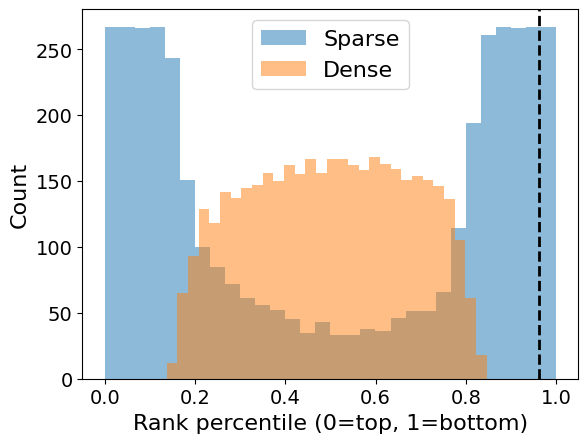

In [36]:
df = ranked_1.copy()

# Merge groups
# df["density_group"] = df["cluster_id"].replace({
#     "1_sparse": "1_Sparse",
#     "0_sparse": "0_Sparse",
#     "1_dense": "1_Dense",
#     "0_dense": "0_Dense"
# })

df["density_group"] = df["cluster_id"].replace({
    "1_sparse": "Sparse",
    "0_sparse": "Sparse",
    "1_dense": "Dense",
    "0_dense": "Dense"
})


df['rank'] = df['Score'].rank(ascending=False, method='average')
n = len(df)
df['rank_pct'] = df['rank'] / (n + 1)

fig, ax = plt.subplots()

# for group in ["1_Sparse", "1_Dense", "0_Sparse", "0_Dense"]:
for group in ["Sparse", "Dense"]:
    x = df.loc[df["density_group"] == group, "rank_pct"]
    ax.hist(x, bins=30, alpha=0.5, density=False, label=group)

ax.set_xlabel('Rank percentile (0=top, 1=bottom)', fontsize=16)
ax.set_ylabel('Count', fontsize=16)
#ax.set_title('Rank-position distribution by density group', fontsize=16)
ax.legend(fontsize=16)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)

first_negative = np.where(df["Score"] < 0)[0]

if len(first_negative) > 0:
    boundary_idx = first_negative[0]

    # Convert to the same rank percentile used in the histogram
    boundary_pct = (boundary_idx + 1) / (len(df) + 1)

    ax.axvline(
        boundary_pct,
        color="black",
        linestyle="--",
        linewidth=2,
        label="Influence = 0"
    )




plt.savefig(
    "SmallLargeDensity_IF_SparseDense_count_newsetting.png",
    dpi=600,
    bbox_inches="tight"
)

plt.show()